In [2]:
"""
This is an efficient re-implementation of SDXL-based P2P (just for reference)
Reference: 
P2P: https://github.com/google/prompt-to-prompt/
P2P-SDXL: https://github.com/RoyiRa/prompt-to-prompt-with-sdxl?tab=readme-ov-file
"""

import torch
import matplotlib.pyplot as plt
from diffusers import StableDiffusionXLPipeline

import sys
sys.path.append("..")
from utils import (
    register_unet_attention_control,
    create_unet_controller,
    unet_p2p_callback,
)

pipe = StableDiffusionXLPipeline.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0", torch_dtype=torch.float16
).to("cuda")

/opt/conda/envs/exp-mmdit/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading pipeline components...: 100%|██████████| 7/7 [00:01<00:00,  6.25it/s]


Registered 140 attention processors.


100%|██████████| 50/50 [00:26<00:00,  1.91it/s]
/opt/conda/envs/exp-mmdit/lib/python3.10/site-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


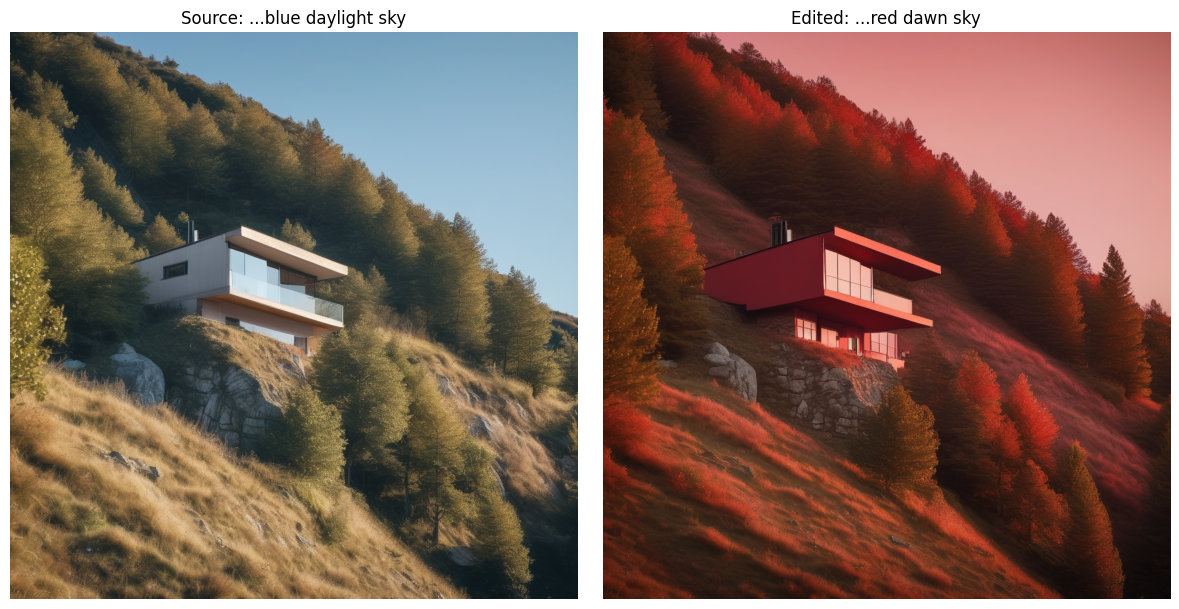

In [3]:
# Replace Example - swapping words

prompts = [
    "House on a mountainside under a clear blue daylight sky",
    "House on a mountainside under a clear red dawn sky",
]
height, width = 1024, 1024

controller = create_unet_controller(
    prompts=prompts,
    num_inference_steps=50,
    tokenizer=pipe.tokenizer,
    device=pipe.device,
    dtype=pipe.dtype,
    edit_type="replace",
    n_cross_replace=0.4,
    n_self_replace=0.4,
    attn_res=(height//32, width//32),
)

register_unet_attention_control(pipe, controller)
images = pipe(
    prompt=prompts,
    num_inference_steps=50,
    guidance_scale=7.5,
    height=height,
    width=width,
    generator=[torch.Generator().manual_seed(864), torch.Generator().manual_seed(864)],
    callback_on_step_end=unet_p2p_callback,
    callback_on_step_end_tensor_inputs=["latents"]
).images

controller.reset()

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(images[0])
ax[0].set_title("Source: ...blue daylight sky")
ax[0].axis("off")
ax[1].imshow(images[1])
ax[1].set_title("Edited: ...red dawn sky")
ax[1].axis("off")
plt.tight_layout()

Registered 140 attention processors.


100%|██████████| 50/50 [00:27<00:00,  1.83it/s]


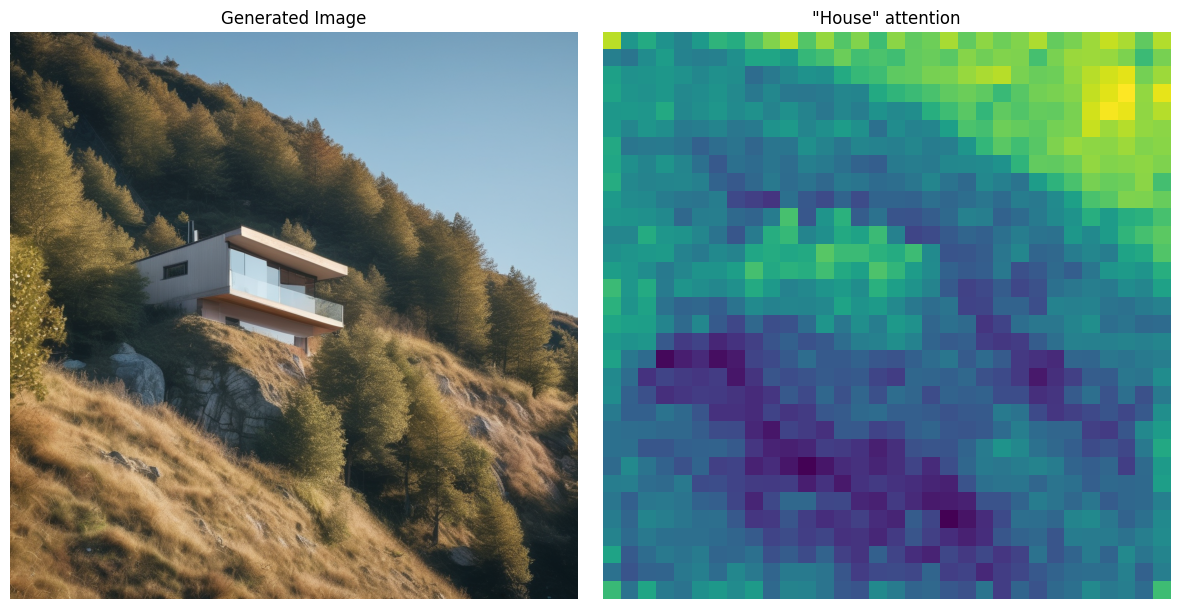

In [4]:
# Attention Visualization of above prompt.

prompt = "House on a mountainside under a clear blue daylight sky"
word = "House"
height, width = 1024, 1024

controller = create_unet_controller(
    prompts=[prompt, prompt],
    num_inference_steps=50,
    tokenizer=pipe.tokenizer,
    device=pipe.device,
    dtype=pipe.dtype,
    edit_type="replace",
    local_blend_words=[word, word],
    local_blend_threshold=0.3,
    attn_res=(height//32, width//32),
)

register_unet_attention_control(pipe, controller)
images = pipe(
    prompt=[prompt, prompt],
    num_inference_steps=50,
    guidance_scale=7.5,
    height=height,
    width=width,
    generator=[torch.Generator().manual_seed(864), torch.Generator().manual_seed(864)],
    callback_on_step_end=unet_p2p_callback,
    callback_on_step_end_tensor_inputs=["latents"]
).images

# Extract attention map
attn_maps = [controller.attention_store[k] for k in ["down_cross", "mid_cross", "up_cross"] 
             if controller.attention_store[k] is not None]
attn = torch.cat(attn_maps, dim=1)[0].mean(0)  # batch[0], mean over heads
attn = attn.view(height//32, width//32).cpu().numpy()
attn = (attn - attn.min()) / (attn.max() - attn.min() + 1e-6)

controller.reset()

# Visualize
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(images[0])
ax[0].set_title("Generated Image")
ax[0].axis("off")
ax[1].imshow(attn, cmap="viridis")
ax[1].set_title(f'"{word}" attention')
ax[1].axis("off")
plt.tight_layout()

Registered 140 attention processors.


100%|██████████| 50/50 [00:27<00:00,  1.81it/s]


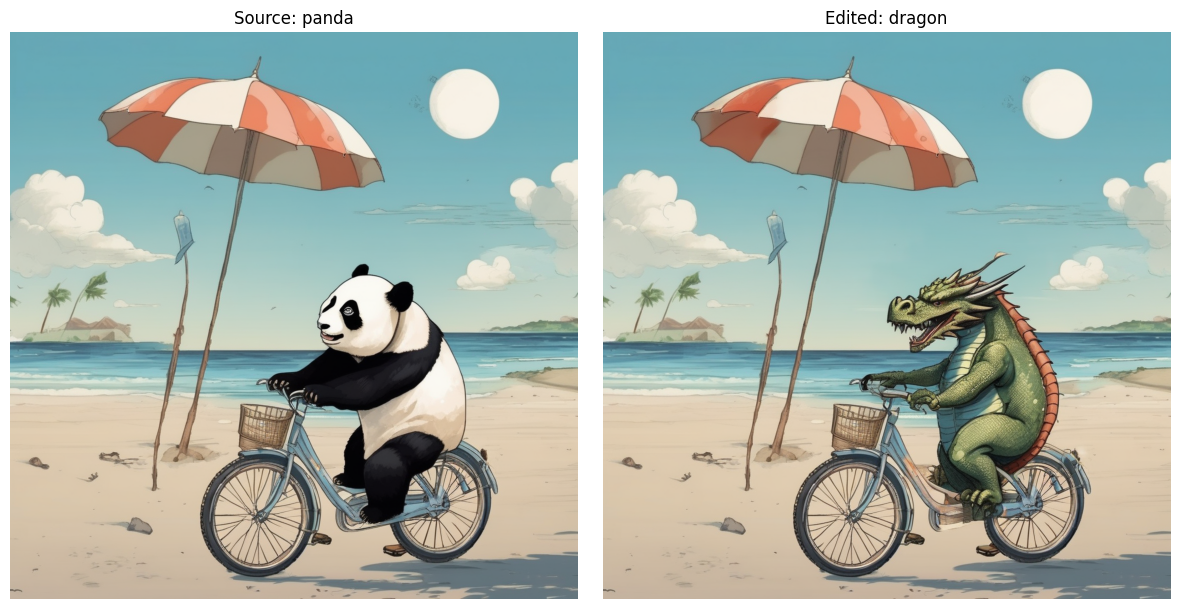

In [5]:
# Replace Example with local blending: try changing the local blend threshold! 

prompts = [
    "a panda riding a bicycle on the beach under blue sky",
    "a dragon riding a bicycle on the beach under blue sky",
]
height, width = 1024, 1024

controller = create_unet_controller(
    prompts=prompts,
    num_inference_steps=50,
    tokenizer=pipe.tokenizer,
    device=pipe.device,
    dtype=pipe.dtype,
    edit_type="replace",
    n_cross_replace=0.4,
    n_self_replace=0.4,
    local_blend_words=["panda", "dragon"],
    local_blend_threshold=0.6,
    attn_res=(height//32, width//32),
)

register_unet_attention_control(pipe, controller)
images = pipe(
    prompt=prompts,
    num_inference_steps=50,
    guidance_scale=7.5,
    height=height,
    width=width,
    generator=[torch.Generator().manual_seed(864), torch.Generator().manual_seed(864)],
    callback_on_step_end=unet_p2p_callback,
    callback_on_step_end_tensor_inputs=["latents"]
).images

controller.reset()

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(images[0])
ax[0].set_title("Source: panda")
ax[0].axis("off")
ax[1].imshow(images[1])
ax[1].set_title("Edited: dragon")
ax[1].axis("off")
plt.tight_layout()

Registered 140 attention processors.


100%|██████████| 50/50 [00:20<00:00,  2.46it/s]


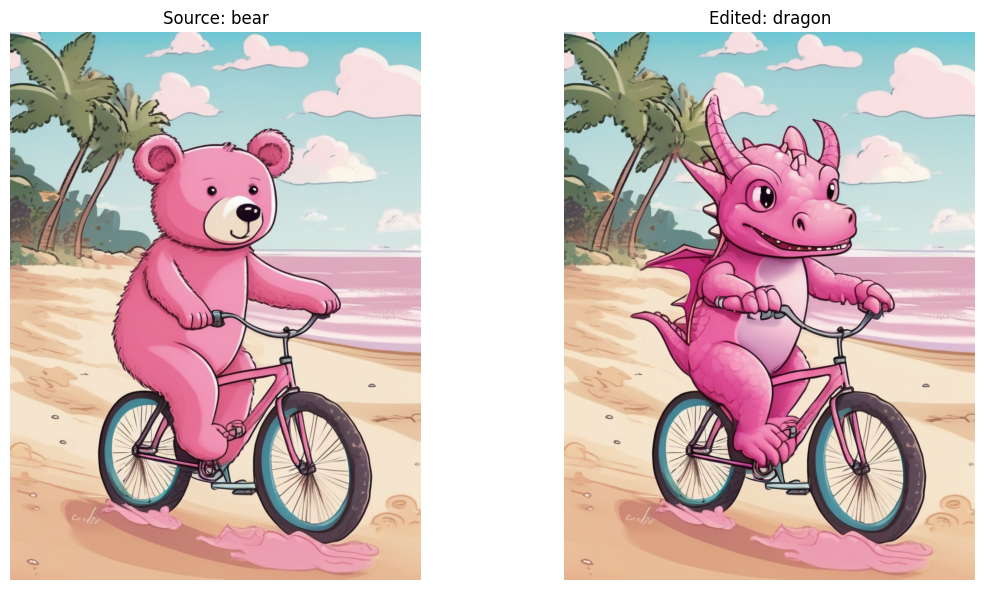

In [6]:
# Replace Example with local blending: You can also adjust the height and width! 

prompts = [
    "a pink bear riding a bicycle on the beach",
    "a pink dragon riding a bicycle on the beach",
]
height, width = 1024, 768

controller = create_unet_controller(
    prompts=prompts,
    num_inference_steps=50,
    tokenizer=pipe.tokenizer,
    device=pipe.device,
    dtype=pipe.dtype,
    edit_type="replace",
    n_cross_replace=0.4,
    n_self_replace=0.4,
    local_blend_words=["bear", "dragon"],
    local_blend_threshold=0.7,
    attn_res=(height//32, width//32),
)

register_unet_attention_control(pipe, controller)
images = pipe(
    prompt=prompts,
    height=height,
    width=width,
    num_inference_steps=50,
    guidance_scale=7.5,
    generator=[torch.Generator().manual_seed(864), torch.Generator().manual_seed(864)],
    callback_on_step_end=unet_p2p_callback,
    callback_on_step_end_tensor_inputs=["latents"]
).images

controller.reset()

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(images[0])
ax[0].set_title("Source: bear")
ax[0].axis("off")
ax[1].imshow(images[1])
ax[1].set_title("Edited: dragon")
ax[1].axis("off")
plt.tight_layout()

Registered 140 attention processors.


100%|██████████| 50/50 [00:27<00:00,  1.81it/s]


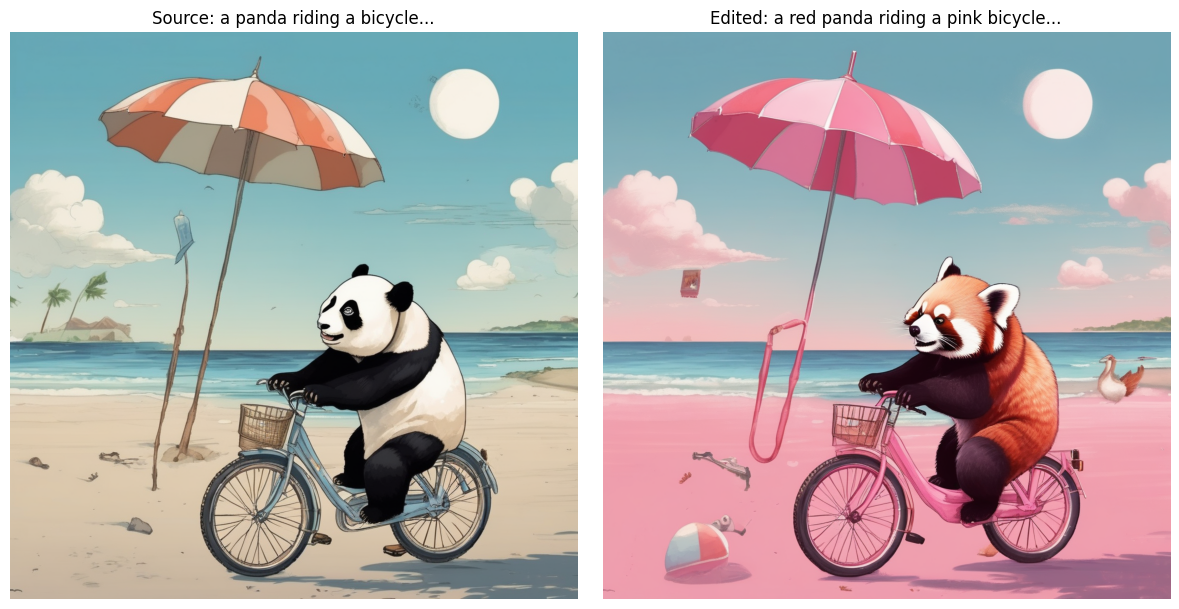

In [7]:
# Refine Example - add style/words to prompt

prompts = [
    "a panda riding a bicycle on the beach under blue sky",
    "a red panda riding a pink bicycle on the beach under blue sky",
]
height, width = 1024, 1024

controller = create_unet_controller(
    prompts=prompts,
    num_inference_steps=50,
    tokenizer=pipe.tokenizer,
    device=pipe.device,
    dtype=pipe.dtype,
    edit_type="refine",
    n_cross_replace=0.4,
    n_self_replace=0.4,
    attn_res=(height//32, width//32),
)

register_unet_attention_control(pipe, controller)
images = pipe(
    prompt=prompts,
    num_inference_steps=50,
    guidance_scale=7.5,
    height=height,
    width=width,
    generator=[torch.Generator().manual_seed(864), torch.Generator().manual_seed(864)],
    callback_on_step_end=unet_p2p_callback,
    callback_on_step_end_tensor_inputs=["latents"]
).images

controller.reset()

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(images[0])
ax[0].set_title("Source: a panda riding a bicycle...")
ax[0].axis("off")
ax[1].imshow(images[1])
ax[1].set_title("Edited: a red panda riding a pink bicycle...")
ax[1].axis("off")
plt.tight_layout()

Registered 140 attention processors.


100%|██████████| 50/50 [00:27<00:00,  1.81it/s]


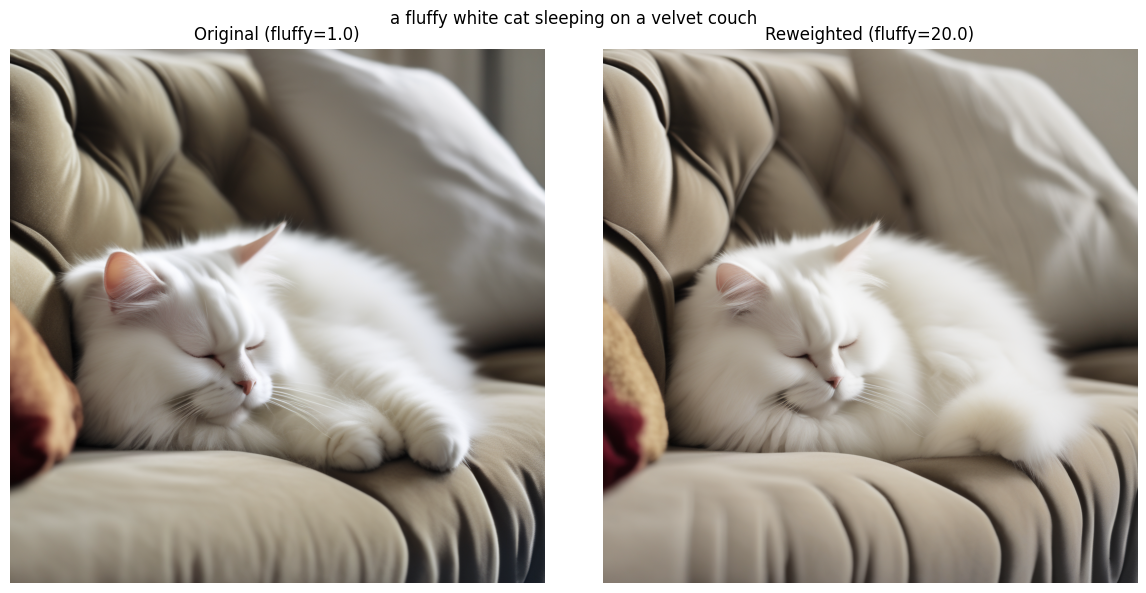

In [8]:
# Reweight Example - strengthen/weaken specific words

prompt = "a fluffy white cat sleeping on a velvet couch"
prompts = [prompt, prompt]
height, width = 1024, 1024

controller = create_unet_controller(
    prompts=prompts,
    num_inference_steps=50,
    tokenizer=pipe.tokenizer,
    device=pipe.device,
    dtype=pipe.dtype,
    edit_type="reweight",
    n_cross_replace=0.4,
    n_self_replace=0.4,
    attn_res=(height//32, width//32),
    equalizer_words=["fluffy"],
    equalizer_strengths=[20.0],
)

register_unet_attention_control(pipe, controller)
images = pipe(
    prompt=prompts,
    num_inference_steps=50,
    guidance_scale=7.5,
    height=height,
    width=width,
    generator=[torch.Generator().manual_seed(864), torch.Generator().manual_seed(864)],
    callback_on_step_end=unet_p2p_callback,
    callback_on_step_end_tensor_inputs=["latents"]
).images

controller.reset()

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(images[0])
ax[0].set_title("Original (fluffy=1.0)")
ax[0].axis("off")
ax[1].imshow(images[1])
ax[1].set_title("Reweighted (fluffy=20.0)")
ax[1].axis("off")
plt.suptitle(prompt)
plt.tight_layout()